## Session 18 - Optional Task (Iris Dataset)

### Iris Dataset - Complete Data Analysis and Preprocessing

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder, StandardScaler

plt.style.use("ggplot")
sns.set_theme(style="whitegrid")

In [3]:
# Load the dataset
df = pd.read_csv("Iris.csv")

# Display first 10 rows
print("First 10 Rows:")
print(df.head(10))

# Display last 5 rows
print("\nLast 5 Rows:")
print(df.tail())

# Display dataset shape
print("\nDataset Shape:")
print(df.shape)

# Display column names
print("\nColumn Names:")
print(df.columns.tolist())

# Display data types
print("\nData Types:")
print(df.dtypes)

# Display dataset information
print("\nDataset Information:")
df.info()

First 10 Rows:
   Id  SepalLengthCm  SepalWidthCm  PetalLengthCm  PetalWidthCm      Species
0   1            5.1           3.5            1.4           0.2  Iris-setosa
1   2            4.9           3.0            1.4           0.2  Iris-setosa
2   3            4.7           3.2            1.3           0.2  Iris-setosa
3   4            4.6           3.1            1.5           0.2  Iris-setosa
4   5            5.0           3.6            1.4           0.2  Iris-setosa
5   6            5.4           3.9            1.7           0.4  Iris-setosa
6   7            4.6           3.4            1.4           0.3  Iris-setosa
7   8            5.0           3.4            1.5           0.2  Iris-setosa
8   9            4.4           2.9            1.4           0.2  Iris-setosa
9  10            4.9           3.1            1.5           0.1  Iris-setosa

Last 5 Rows:
      Id  SepalLengthCm  SepalWidthCm  PetalLengthCm  PetalWidthCm  \
145  146            6.7           3.0            5.2  

In [4]:
# Check missing values
print("Missing Values:")
print(df.isnull().sum())

# Check duplicate rows
duplicate_count = df.duplicated().sum()

print("\nDuplicate Rows:", duplicate_count)

# Remove duplicate rows
df = df.drop_duplicates()

print("\nDuplicate Rows After Removal:")
print(df.duplicated().sum())

Missing Values:
Id               0
SepalLengthCm    0
SepalWidthCm     0
PetalLengthCm    0
PetalWidthCm     0
Species          0
dtype: int64

Duplicate Rows: 0

Duplicate Rows After Removal:
0


In [5]:
# Display statistical summary
print("Statistical Summary:")
print(df.describe())

# Statistics for important numeric columns
columns = [
    "SepalLengthCm",
    "SepalWidthCm",
    "PetalLengthCm",
    "PetalWidthCm"
]

for col in columns:
    print(f"\n{col} Statistics")
    print("Minimum :", df[col].min())
    print("Maximum :", df[col].max())
    print("Mean    :", df[col].mean())
    print("Median  :", df[col].median())

Statistical Summary:
               Id  SepalLengthCm  SepalWidthCm  PetalLengthCm  PetalWidthCm
count  150.000000     150.000000    150.000000     150.000000    150.000000
mean    75.500000       5.843333      3.054000       3.758667      1.198667
std     43.445368       0.828066      0.433594       1.764420      0.763161
min      1.000000       4.300000      2.000000       1.000000      0.100000
25%     38.250000       5.100000      2.800000       1.600000      0.300000
50%     75.500000       5.800000      3.000000       4.350000      1.300000
75%    112.750000       6.400000      3.300000       5.100000      1.800000
max    150.000000       7.900000      4.400000       6.900000      2.500000

SepalLengthCm Statistics
Minimum : 4.3
Maximum : 7.9
Mean    : 5.843333333333334
Median  : 5.8

SepalWidthCm Statistics
Minimum : 2.0
Maximum : 4.4
Mean    : 3.0540000000000003
Median  : 3.0

PetalLengthCm Statistics
Minimum : 1.0
Maximum : 6.9
Mean    : 3.758666666666666
Median  : 4.35

Petal

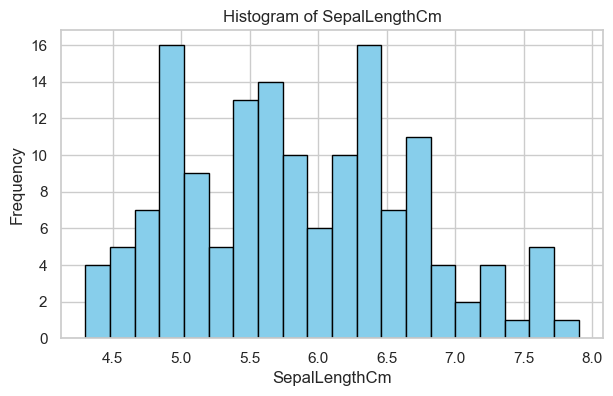

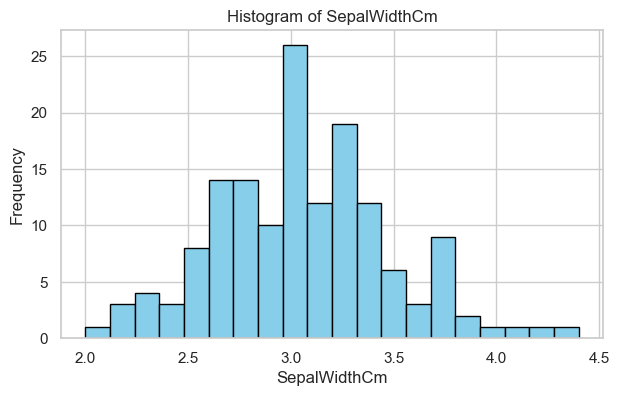

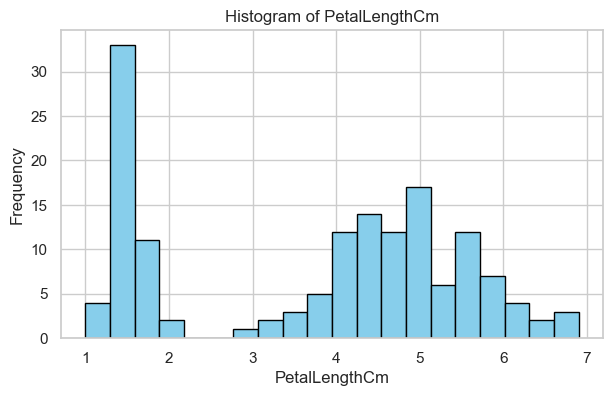

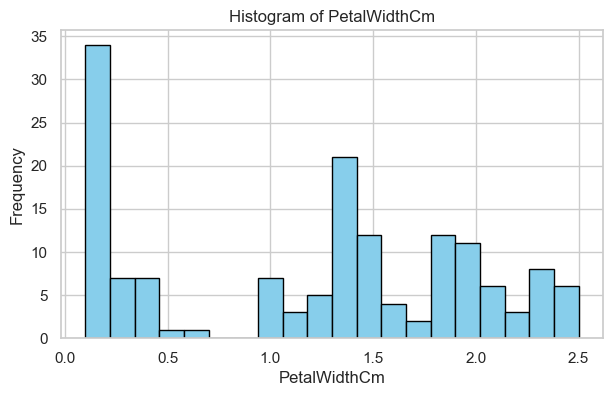

In [6]:
# Numeric columns
numeric_columns = [
    "SepalLengthCm",
    "SepalWidthCm",
    "PetalLengthCm",
    "PetalWidthCm"
]

# Plot histograms
for col in numeric_columns:

    plt.figure(figsize=(7,4))

    plt.hist(df[col], bins=20, edgecolor="black", color="skyblue")

    plt.title(f"Histogram of {col}")
    plt.xlabel(col)
    plt.ylabel("Frequency")

    plt.show()

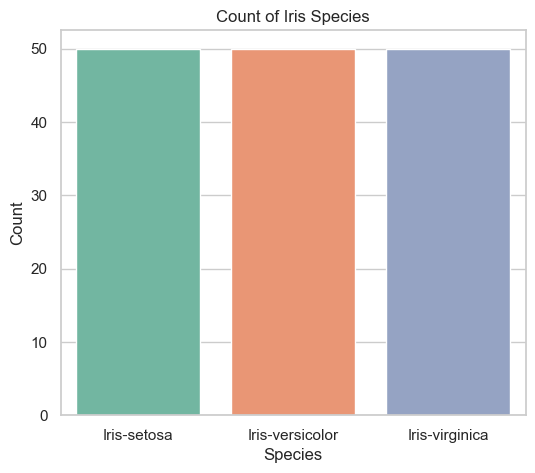

In [7]:
# Count plot for species

plt.figure(figsize=(6,5))

sns.countplot(
    data=df,
    x="Species",
    hue="Species",
    palette="Set2",
    legend=False
)

plt.title("Count of Iris Species")
plt.xlabel("Species")
plt.ylabel("Count")

plt.show()

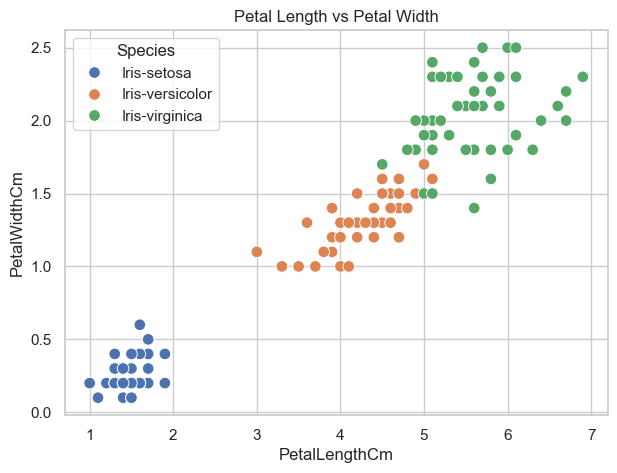

In [8]:
# Scatter plot between Petal Length and Petal Width

plt.figure(figsize=(7,5))

sns.scatterplot(
    data=df,
    x="PetalLengthCm",
    y="PetalWidthCm",
    hue="Species",
    s=70
)

plt.title("Petal Length vs Petal Width")

plt.show()

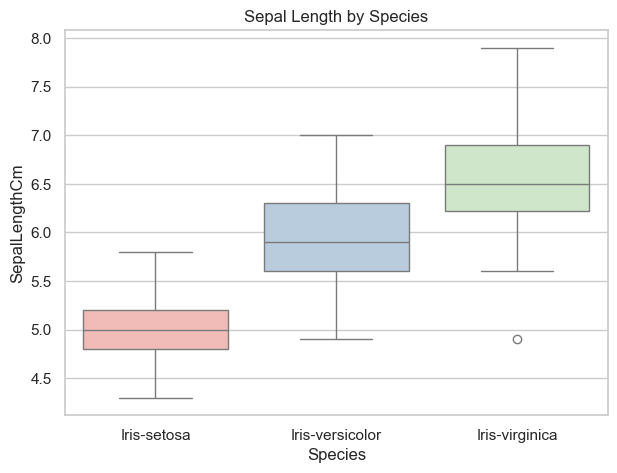

In [11]:
# Box plot of Sepal Length by Species

plt.figure(figsize=(7,5))

sns.boxplot(
    data=df,
    x="Species",
    y="SepalLengthCm",
    hue="Species",
    palette="Pastel1",
    legend=False
)

plt.title("Sepal Length by Species")

plt.show()

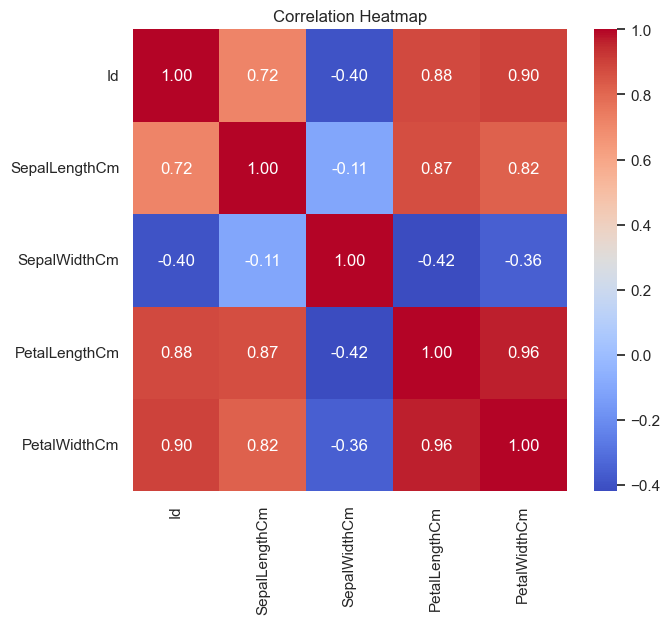

In [12]:
# Select numeric columns
numeric_df = df.select_dtypes(include="number")

# Correlation matrix
corr_matrix = numeric_df.corr()

# Plot heatmap
plt.figure(figsize=(7,6))

sns.heatmap(
    corr_matrix,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Heatmap")

plt.show()

In [13]:
# Independent features
X = df.drop("Species", axis=1)

# Remove Id column if present
if "Id" in X.columns:
    X = X.drop("Id", axis=1)

# Dependent feature
y = df["Species"]

print("Independent Features:")
print(X.columns.tolist())

print("\nDependent Feature:")
print(y.name)

Independent Features:
['SepalLengthCm', 'SepalWidthCm', 'PetalLengthCm', 'PetalWidthCm']

Dependent Feature:
Species


In [14]:
# Display target values before encoding
print("Before Label Encoding:")
print(df["Species"].head())

# Apply Label Encoding
encoder = LabelEncoder()

df["Species"] = encoder.fit_transform(df["Species"])

# Display target values after encoding
print("\nAfter Label Encoding:")
print(df["Species"].head())

# Display class mapping
print("\nClass Mapping:")
for index, label in enumerate(encoder.classes_):
    print(f"{label} --> {index}")

Before Label Encoding:
0    Iris-setosa
1    Iris-setosa
2    Iris-setosa
3    Iris-setosa
4    Iris-setosa
Name: Species, dtype: object

After Label Encoding:
0    0
1    0
2    0
3    0
4    0
Name: Species, dtype: int64

Class Mapping:
Iris-setosa --> 0
Iris-versicolor --> 1
Iris-virginica --> 2


In [15]:
# Define input and output features
X = df.drop("Species", axis=1)

# Remove Id column if present
if "Id" in X.columns:
    X = X.drop("Id", axis=1)

y = df["Species"]

# Apply Standard Scaling
scaler = StandardScaler()

scaled_data = scaler.fit_transform(X)

# Convert to DataFrame
scaled_df = pd.DataFrame(
    scaled_data,
    columns=X.columns
)

# Display first 5 rows
print("First 5 Rows of Scaled Data:")
print(scaled_df.head())

First 5 Rows of Scaled Data:
   SepalLengthCm  SepalWidthCm  PetalLengthCm  PetalWidthCm
0      -0.900681      1.032057      -1.341272     -1.312977
1      -1.143017     -0.124958      -1.341272     -1.312977
2      -1.385353      0.337848      -1.398138     -1.312977
3      -1.506521      0.106445      -1.284407     -1.312977
4      -1.021849      1.263460      -1.341272     -1.312977


In [16]:
# Remove duplicate rows
df = df.drop_duplicates()

# Define input and output features
X = df.drop("Species", axis=1)

# Remove Id column if present
if "Id" in X.columns:
    X = X.drop("Id", axis=1)

y = df["Species"]

# Encode target variable
encoder = LabelEncoder()
y = encoder.fit_transform(y)

# Scale input features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Convert scaled data to DataFrame
X_scaled = pd.DataFrame(
    X_scaled,
    columns=X.columns
)

print("Preprocessed Features:")
print(X_scaled.head())

print("\nEncoded Target:")
print(y[:5])

print("\nPreprocessing completed successfully.")

Preprocessed Features:
   SepalLengthCm  SepalWidthCm  PetalLengthCm  PetalWidthCm
0      -0.900681      1.032057      -1.341272     -1.312977
1      -1.143017     -0.124958      -1.341272     -1.312977
2      -1.385353      0.337848      -1.398138     -1.312977
3      -1.506521      0.106445      -1.284407     -1.312977
4      -1.021849      1.263460      -1.341272     -1.312977

Encoded Target:
[0 0 0 0 0]

Preprocessing completed successfully.


### Summary

• **Dataset Overview**

* Explored the Iris dataset containing measurements of three Iris flower species: Setosa, Versicolor, and Virginica.
* The dataset consists of four numerical features and one target (species) column.

• **Data Exploration**

* Loaded and explored the dataset.
* Checked the shape, columns, and data types.

• **Data Cleaning**

* Checked for missing values and duplicate records.
* Verified the dataset was clean and ready for analysis.

• **Data Analysis**

* Generated summary statistics.
* Created histograms, count plots, scatter plots, box plots, and a correlation heatmap.
* Analyzed the distribution and relationships among the flower measurements.

• **Preprocessing**

* Identified the input and target features.
* Applied Label Encoding (or One Hot Encoding, if required) to the target variable.
* Applied Standard Scaling to the numerical features.

• **Key Learning**

* Learned the complete data preprocessing workflow for a classification dataset.
* Understood how flower measurements can be used to classify different Iris species.
* Prepared the dataset for classification machine learning models.
